In [20]:
import torch
import torch.nn as nn
from torch.optim import Adam


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import gymnasium as gym

In [22]:
env = gym.make("LunarLander",
            continuous=False,
            render_mode='rgb_array')

c:\Users\Ashutosh Thapa\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\envs\registration.py:520: UserWarning: WARN: Using the latest versioned environment `LunarLander-v3` instead of the unversioned environment `LunarLander`.
  logger.warn(


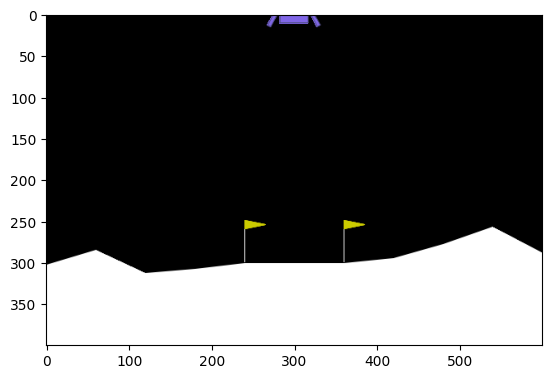

In [23]:
obs,info = env.reset()
img = env.render()
plt.imshow(img)

In [24]:
print(obs)
info

[-1.2898445e-03  1.4043441e+00 -1.3067491e-01 -2.9226190e-01
  1.5015273e-03  2.9599825e-02  0.0000000e+00  0.0000000e+00]


{}

In [37]:
class DQN(nn.Module):

    def __init__(self,n_states,n_actions):
        super().__init__()
        self.n_states = n_states
        self.n_actions = n_actions

        self.shared = nn.Sequential(
            nn.Linear(self.n_states,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU()
        )

        self.value = nn.Sequential(
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )

        self.advantage = nn.Sequential(
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,self.n_actions)
        )

    def forward(self,states):
         
         shared = self.shared(states)

         V = self.value(shared)

         A = self.advantage(shared)

         Q = V + (A - A.mean(dim=1, keepdim=True))

         return Q

    
            
            

In [42]:
class PrioterizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = []
        self.priorities = []
        self.pos = 0

    def append(self,transition):
        max_priority = max(self.priorities, default=1.0)
        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
            self.priorities.append(max_priority)

        else:
            self.buffer[self.pos] = transition
            self.priorities[self.pos] = max_priority
        self.pos = (self.pos + 1) % self.capacity

    def sample(self,batch_size, beta=0.4):
        priorities = np.array(self.priorities) ** self.alpha
        probs = priorities / priorities.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        batch = [self.buffer[i] for i in indices]

        weights = (len(self.buffer) * probs[indices]) ** (-beta)
        weights /= weights.max()

        return indices, batch, torch.tensor(weights, dtype=torch.float32)

    def update_priorities(self,indices,td_errors,epsilon=1e-5):
        for i,td in zip(indices,td_errors):
            self.priorities[i] = abs(td) + epsilon

    def __len__(self):
        return len(self.buffer)
    

In [43]:

class DQNAgent:

    def __init__(self,env,n_states,n_actions,n_episodes,gamma=0.99,epsilon=1,epsilon_dec=0.9990,epsilon_min=0.01):
        self.env = env
        self.epsilon = epsilon
        self.gamma = gamma
        self.n_episodes = n_episodes
        self.n_actions = n_actions
        self.n_states = n_states
        self.epsilon_dec = epsilon_dec
        self.epsilon_min = epsilon_min

        self.total_steps = 0
        self.lr = 1e-3
        self.memory = PrioterizedReplayBuffer(capacity=100000)
        self.target_update_steps = 500
        self.batch_size = 128
        self.steps = 0
        self.loss_value = 0

        self.reward_per_10epi = []
        self.epino_forplot = []
        self.all_rewards=[]

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.online_net = DQN(n_states,n_actions)
        self.online_net.to(self.device)
        self.target_net = DQN(n_states,n_actions)
        self.target_net.to(self.device)

        self.optimizer = Adam(self.online_net.parameters(),lr=self.lr)
        self.loss = nn.SmoothL1Loss(reduction="none") 
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()



    def select_action(self,state):

        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        else:

            state = torch.tensor(state).unsqueeze(0).to(self.device)

            with torch.no_grad():
                q_vals = self.online_net(state)
            return torch.argmax(q_vals).item()


    def replay_buffer(self):

        if len(self.memory) < self.batch_size:
            return
        if self.total_steps % 8 != 0:
            return

        
        indices, batch_data, weights = self.memory.sample(self.batch_size)
        weights = weights.unsqueeze(1).to(self.device)
        states ,actions, rewards, next_states ,done = zip(*batch_data)
        
        states = torch.tensor(states, dtype=torch.float32).to(self.device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(self.device)
        actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(self.device)
        done = torch.tensor(done, dtype=torch.float32).unsqueeze(1).to(self.device)

        currentQ = self.online_net(states).gather(1,actions)

        with torch.no_grad():
            nextQ = self.target_net(next_states).max(1,keepdim=True)[0]
            targetQ = rewards + self.gamma * nextQ * (1-done)

        
        td_errors = (targetQ - currentQ).detach().cpu().numpy().flatten()
        loss = (weights * self.loss(currentQ, targetQ)).mean()
        self.loss_value += loss.item()
        self.optimizer.zero_grad()
        loss.backward() #backprop
        nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=1.0)
        self.optimizer.step()
        self.memory.update_priorities(indices, td_errors)
        self.steps += 1

        if self.steps % self.target_update_steps == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        
    def train(self):
        
        for episode in range(self.n_episodes):
            state,info = env.reset()
            state = state
            total_reward = 0
            done = False

            
            while not done:
                
                action = self.select_action(state)
                next_state, reward, ternimated, truncated, _ = self.env.step(action)

                done = ternimated or truncated

                total_reward += reward

                self.memory.append((state,action,reward,next_state,done))

                state = next_state

                self.total_steps += 1
                
                self.replay_buffer()

            if episode%10 == 0:
                self.epino_forplot.append(episode)
                avg_reward = np.mean(self.all_rewards[-10:])
                self.reward_per_10epi.append(avg_reward)


            self.epsilon = max(self.epsilon_min,self.epsilon*self.epsilon_dec)
            self.all_rewards.append(total_reward)

                
            if episode%100 ==0:
                print(f"Episode {episode}, Reward {np.mean(self.all_rewards[-100:])}, Epsilon {self.epsilon:.4f}")
        
        
    def plot(self):
        plt.plot(self.epino_forplot, self.reward_per_10epi)
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.title("DQN Training Progress")
        plt.show()


            
    


In [44]:
Agent = DQNAgent(env,8,4,2500)

In [45]:
Agent.train()

Episode 0, Reward -63.187569423342744, Epsilon 0.9990
Episode 100, Reward -172.49575389674152, Epsilon 0.9039
Episode 200, Reward -130.8272372620742, Epsilon 0.8178
Episode 300, Reward -109.0071102674133, Epsilon 0.7400
Episode 400, Reward -76.09862281711085, Epsilon 0.6695
Episode 500, Reward -65.1538407124416, Epsilon 0.6058
Episode 600, Reward -50.170877760759524, Epsilon 0.5481
Episode 700, Reward -52.68488904365929, Epsilon 0.4959
Episode 800, Reward -23.59376209441236, Epsilon 0.4487
Episode 900, Reward -11.601062884368009, Epsilon 0.4060
Episode 1000, Reward 2.435399589454266, Epsilon 0.3673
Episode 1100, Reward 21.723813273225666, Epsilon 0.3324
Episode 1200, Reward 37.49709989589578, Epsilon 0.3007
Episode 1300, Reward 43.34661315951131, Epsilon 0.2721
Episode 1400, Reward 89.80952669412896, Epsilon 0.2462
Episode 1500, Reward 73.86072040793488, Epsilon 0.2227
Episode 1600, Reward 92.80664108460516, Epsilon 0.2015
Episode 1700, Reward 100.74382482893297, Epsilon 0.1823
Episode

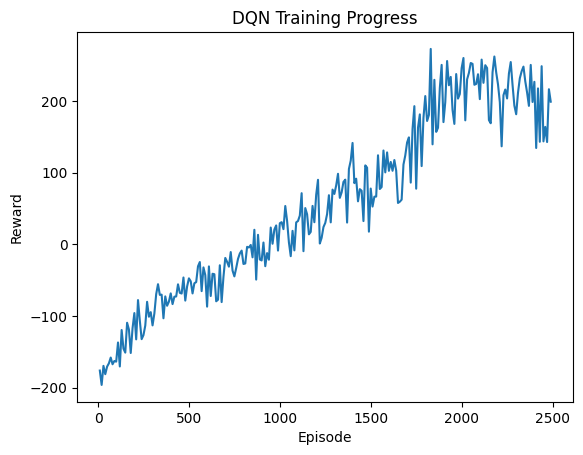

In [46]:
Agent.plot()

In [48]:
torch.save(Agent.online_net.state_dict(), "PER-LunarLander-Online_net.pth")

In [49]:
env = gym.make("LunarLander-v3",render_mode = "human")
agent = DQNAgent(env,8,4,2500)
agent.online_net.load_state_dict(torch.load("PER-LunarLander-Online_net.pth"))
agent.online_net.eval()

for i in range (3):
    state,_ = env.reset()
    done = False
    total_reward = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    while not done:
        with torch.no_grad():
            state = torch.tensor(state).unsqueeze(0).to(device)
            action = torch.argmax(agent.online_net(state)).item()
        next_state, reward, term, trunc, _ = env.step(action)
        total_reward += reward
        done = term or trunc
        state = next_state
    
    print(f'Total Reward This Episode: {total_reward}')
env.close()
            

Total Reward This Episode: 312.4132007724837
Total Reward This Episode: 251.4295454290121
Total Reward This Episode: 28.175999916936803
